In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [39]:
df_estimates = pd.read_excel("data\\Anthony-Estimates-of-water-use-(2000-2020).xlsx")
df_regions = pd.read_excel("data\\Anthony-Regions-dataset.xlsx", skiprows=1)

In [40]:
df_estimates.head()

,name,year,pop_n,pop_u,wat_bas_n,wat_lim_n,wat_unimp_n,wat_sur_n,wat_bas_r,wat_lim_r,wat_unimp_r,wat_sur_r,wat_bas_u,wat_lim_u,wat_unimp_u,wat_sur_u
0,Croatia,2020,4105.268066,57.552998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,0.0,0.000000,0.0
1,Croatia,2015,4232.874023,56.155003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,0.0,0.000000,0.0
2,Argentina,2020,45195.777340,92.111000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.790421,0.0,0.209579,0.0
3,Greece,2015,10659.737300,78.046005,100.000005,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.000000,0.0,0.000000,0.0
4,Andorra,2020,77.264999,87.916000,100.000004,0.0,0.0,0.0,100.0,0.0,0.0,0.0,100.000000,0.0,0.000000,0.0


In [41]:
# Accessing afghanistan's data
afghanistan_data = df_estimates[df_estimates['name'] == 'Afghanistan']
print(afghanistan_data)

            name  year        pop_n      pop_u  wat_bas_n  wat_lim_n  \
379  Afghanistan  2020  38928.33984  26.025999  75.091413   1.447542   
422  Afghanistan  2015  34413.60156  24.802999  61.339781   3.511200   

     wat_unimp_n  wat_sur_n  wat_bas_r  wat_lim_r  wat_unimp_r  wat_sur_r  \
379    14.560263   8.900782  66.327915   1.956825    19.682949  12.032311   
422    22.168784  12.980236  52.988502   3.861137    26.553268  16.597094   

      wat_bas_u  wat_lim_u  wat_unimp_u  wat_sur_u  
379  100.000000   0.000000     0.000000   0.000000  
422   86.658941   2.450271     8.876036   2.014753  


In [42]:
df_regions.head()

,name,region
0,Afghanistan,South Asia
1,Albania,Europe & Central Asia
2,Algeria,Middle East & North Africa
3,American Samoa,East Asia & Pacific
4,Andorra,Europe & Central Asia


In [43]:
df_estimates.columns

Index(['name', 'year', 'pop_n', 'pop_u', 'wat_bas_n', 'wat_lim_n',
       'wat_unimp_n', 'wat_sur_n', 'wat_bas_r', 'wat_lim_r', 'wat_unimp_r',
       'wat_sur_r', 'wat_bas_u', 'wat_lim_u', 'wat_unimp_u', 'wat_sur_u'],
      dtype='str')

In [44]:
# sorting the estimates by name and year
df_estimates.sort_values(by=["name", "year"], inplace=True)

In [45]:
df_estimates.head()

,name,year,pop_n,pop_u,wat_bas_n,wat_lim_n,wat_unimp_n,wat_sur_n,wat_bas_r,wat_lim_r,wat_unimp_r,wat_sur_r,wat_bas_u,wat_lim_u,wat_unimp_u,wat_sur_u
422,Afghanistan,2015,34413.601560,24.802999,61.339781,3.511200,22.168784,12.980236,52.988502,3.861137,26.553268,16.597094,86.658941,2.450271,8.876036,2.014753
379,Afghanistan,2020,38928.339840,26.025999,75.091413,1.447542,14.560263,8.900782,66.327915,1.956825,19.682949,12.032311,100.000000,0.000000,0.000000,0.000000
297,Albania,2015,2890.523926,57.433998,93.394325,3.626384,2.979291,0.000000,90.627275,5.263173,4.109553,0.000000,95.445067,2.413312,2.141621,0.000000
270,Albania,2020,2877.800049,62.112000,95.068039,1.884656,3.047305,0.000000,94.091358,2.305265,3.603377,0.000000,95.663809,1.628087,2.708104,0.000000
296,Algeria,2015,39728.019530,70.848000,93.409562,5.157781,1.275465,0.157193,88.352707,8.685753,2.580432,0.381108,95.490315,3.706117,0.738510,0.065058


In [46]:
# Calculate the average difference in years for data entries per country and save it in new column 'y_diff'
df_estimates['y_diff'] = df_estimates.groupby('name')['year'].diff()
df_estimates.head()

,name,year,pop_n,pop_u,wat_bas_n,wat_lim_n,wat_unimp_n,wat_sur_n,wat_bas_r,wat_lim_r,wat_unimp_r,wat_sur_r,wat_bas_u,wat_lim_u,wat_unimp_u,wat_sur_u,y_diff
422,Afghanistan,2015,34413.601560,24.802999,61.339781,3.511200,22.168784,12.980236,52.988502,3.861137,26.553268,16.597094,86.658941,2.450271,8.876036,2.014753,NaN
379,Afghanistan,2020,38928.339840,26.025999,75.091413,1.447542,14.560263,8.900782,66.327915,1.956825,19.682949,12.032311,100.000000,0.000000,0.000000,0.000000,5.0
297,Albania,2015,2890.523926,57.433998,93.394325,3.626384,2.979291,0.000000,90.627275,5.263173,4.109553,0.000000,95.445067,2.413312,2.141621,0.000000,NaN
270,Albania,2020,2877.800049,62.112000,95.068039,1.884656,3.047305,0.000000,94.091358,2.305265,3.603377,0.000000,95.663809,1.628087,2.708104,0.000000,5.0
296,Algeria,2015,39728.019530,70.848000,93.409562,5.157781,1.275465,0.157193,88.352707,8.685753,2.580432,0.381108,95.490315,3.706117,0.738510,0.065058,NaN


In [47]:
# Remove the duplicate entries based on y_diff if its zero
df_estimates = df_estimates[df_estimates['y_diff'] != 0]
df_estimates.head()

,name,year,pop_n,pop_u,wat_bas_n,wat_lim_n,wat_unimp_n,wat_sur_n,wat_bas_r,wat_lim_r,wat_unimp_r,wat_sur_r,wat_bas_u,wat_lim_u,wat_unimp_u,wat_sur_u,y_diff
422,Afghanistan,2015,34413.601560,24.802999,61.339781,3.511200,22.168784,12.980236,52.988502,3.861137,26.553268,16.597094,86.658941,2.450271,8.876036,2.014753,NaN
379,Afghanistan,2020,38928.339840,26.025999,75.091413,1.447542,14.560263,8.900782,66.327915,1.956825,19.682949,12.032311,100.000000,0.000000,0.000000,0.000000,5.0
297,Albania,2015,2890.523926,57.433998,93.394325,3.626384,2.979291,0.000000,90.627275,5.263173,4.109553,0.000000,95.445067,2.413312,2.141621,0.000000,NaN
270,Albania,2020,2877.800049,62.112000,95.068039,1.884656,3.047305,0.000000,94.091358,2.305265,3.603377,0.000000,95.663809,1.628087,2.708104,0.000000,5.0
296,Algeria,2015,39728.019530,70.848000,93.409562,5.157781,1.275465,0.157193,88.352707,8.685753,2.580432,0.381108,95.490315,3.706117,0.738510,0.065058,NaN


In [48]:
df_estimates['y_diff'].mean()

np.float64(4.796536796536796)

In [49]:
# calculate the average year difference across all countries, rounded to two decimal places
average_year_diff = round(df_estimates['y_diff'].mean(), 2)
average_year_diff

np.float64(4.8)

In [50]:
# Calculate the minimum and maximum year difference in the same way
min_year_diff = df_estimates['y_diff'].min()
max_year_diff = df_estimates['y_diff'].max()
print(f"Average Year Difference: {average_year_diff}")
print(f"Minimum Year Difference: {min_year_diff}")

Average Year Difference: 4.8
Minimum Year Difference: 1.0


In [51]:
# How does the average year difference compare to the minimum and maximum year difference? 
print(f"Average Year Difference: {average_year_diff}")
print(f"Minimum Year Difference: {min_year_diff}")
print(f"Maximum Year Difference: {max_year_diff}")

Average Year Difference: 4.8
Minimum Year Difference: 1.0
Maximum Year Difference: 5.0


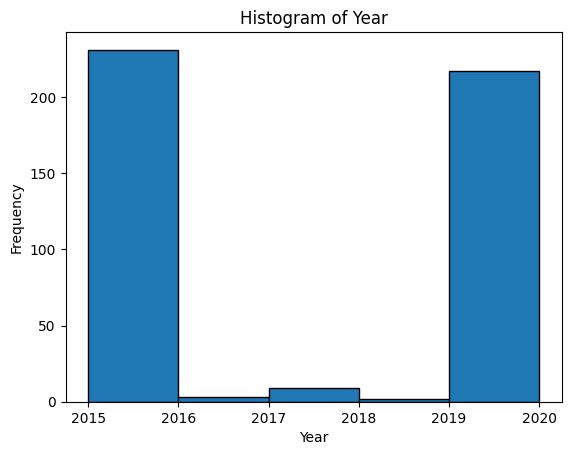

In [52]:
# create a histogram of the year column. Note the minimum and maximum values on the horizontal axis.
import matplotlib.pyplot as plt

plt.hist(df_estimates['year'], bins=range(df_estimates['year'].min(), df_estimates['year'].max() + 1), edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Histogram of Year')
plt.show()

In [53]:
# Calculate Annual Rates of Change (ARC)
"""
ARC_n (national) we calculate using wat_bas_n, ARC_r (rural)
using wat_bas_r and ARC_u (urban) using wat_bas_u. Remember, our wat_bas_x values are already in
percentages.
this is the equation for calculating the ARC:
ARC_x = (wat_bas_x(n+1) - wat_bas_x(n))/(year(n+1) - year(n))

"""
df_estimates['ARC_n'] = df_estimates.groupby('name')['wat_bas_n'].diff() / df_estimates.groupby('name')['year'].diff()
df_estimates['ARC_r'] = df_estimates.groupby('name')['wat_bas_r'].diff() / df_estimates.groupby('name')['year'].diff()
df_estimates['ARC_u'] = df_estimates.groupby('name')['wat_bas_u'].diff() / df_estimates.groupby('name')['year'].diff()

In [54]:
df_estimates.head()

,name,year,pop_n,pop_u,wat_bas_n,wat_lim_n,wat_unimp_n,wat_sur_n,wat_bas_r,wat_lim_r,wat_unimp_r,wat_sur_r,wat_bas_u,wat_lim_u,wat_unimp_u,wat_sur_u,y_diff,ARC_n,ARC_r,ARC_u
422,Afghanistan,2015,34413.601560,24.802999,61.339781,3.511200,22.168784,12.980236,52.988502,3.861137,26.553268,16.597094,86.658941,2.450271,8.876036,2.014753,NaN,NaN,NaN,NaN
379,Afghanistan,2020,38928.339840,26.025999,75.091413,1.447542,14.560263,8.900782,66.327915,1.956825,19.682949,12.032311,100.000000,0.000000,0.000000,0.000000,5.0,2.750326,2.667883,2.668212
297,Albania,2015,2890.523926,57.433998,93.394325,3.626384,2.979291,0.000000,90.627275,5.263173,4.109553,0.000000,95.445067,2.413312,2.141621,0.000000,NaN,NaN,NaN,NaN
270,Albania,2020,2877.800049,62.112000,95.068039,1.884656,3.047305,0.000000,94.091358,2.305265,3.603377,0.000000,95.663809,1.628087,2.708104,0.000000,5.0,0.334743,0.692817,0.043748
296,Algeria,2015,39728.019530,70.848000,93.409562,5.157781,1.275465,0.157193,88.352707,8.685753,2.580432,0.381108,95.490315,3.706117,0.738510,0.065058,NaN,NaN,NaN,NaN


In [55]:
# Accessing Annual Rates of Change (ARC)
df_estimates[['name', 'year', 'ARC_n', 'ARC_r', 'ARC_u']].head()

,name,year,ARC_n,ARC_r,ARC_u
422,Afghanistan,2015,NaN,NaN,NaN
379,Afghanistan,2020,2.750326,2.667883,2.668212
297,Albania,2015,NaN,NaN,NaN
270,Albania,2020,0.334743,0.692817,0.043748
296,Algeria,2015,NaN,NaN,NaN


In [56]:
# Calculate the average, minimum, and maximum for each of the ARC values for access to the basic service level for each of the three population groups.
arc_n_avg = df_estimates['ARC_n'].mean()
arc_n_min = df_estimates['ARC_n'].min()
arc_n_max = df_estimates['ARC_n'].max()
arc_r_avg = df_estimates['ARC_r'].mean()
arc_r_min = df_estimates['ARC_r'].min()
arc_r_max = df_estimates['ARC_r'].max()
arc_u_avg = df_estimates['ARC_u'].mean()
arc_u_min = df_estimates['ARC_u'].min()
arc_u_max = df_estimates['ARC_u'].max()
print(f"ARC_n - Average: {arc_n_avg}, Minimum: {arc_n_min}, Maximum: {arc_n_max}")
print(f"ARC_r - Average: {arc_r_avg}, Minimum: {arc_r_min}, Maximum: {arc_r_max}")
print(f"ARC_u - Average: {arc_u_avg}, Minimum: {arc_u_min}, Maximum: {arc_u_max}")


ARC_n - Average: 0.2769960820917031, Minimum: -1.0217886739999997, Maximum: 2.7503264880000002
ARC_r - Average: 0.48445493171257475, Minimum: -1.2273809599999992, Maximum: 2.6678826380000005
ARC_u - Average: 0.1544626368618785, Minimum: -1.6200868119999996, Maximum: 2.668211855999999


In [57]:
# calculate the number of countries that have missing ARC values, i.e., the number of “null” occurrences in each of the columns ARC_n, ARC_r, and ARC_u.
arc_n_missing = df_estimates['ARC_n'].isnull().sum()
arc_r_missing = df_estimates['ARC_r'].isnull().sum()
arc_u_missing = df_estimates['ARC_u'].isnull().sum()
print(f"Number of countries with missing ARC_n values: {arc_n_missing}")
print(f"Number of countries with missing ARC_r values: {arc_r_missing}")
print(f"Number of countries with missing ARC_u values: {arc_u_missing}")

Number of countries with missing ARC_n values: 233
Number of countries with missing ARC_r values: 295
Number of countries with missing ARC_u values: 281


In [58]:
# calculate the number of countries that have full access across both years, i.e., the number of countries where access is 100% for both years reported.
full_access_n = df_estimates[(df_estimates['wat_bas_n'] == 100) & (df_estimates['y_diff'] > 0)].groupby('name').filter(lambda x: len(x) > 1)['name'].nunique()
full_access_r = df_estimates[(df_estimates['wat_bas_r'] == 100) & (df_estimates['y_diff'] > 0)].groupby('name').filter(lambda x: len(x) > 1)['name'].nunique()
full_access_u = df_estimates[(df_estimates['wat_bas_u'] == 100  ) & (df_estimates['y_diff'] > 0)].groupby('name').filter(lambda x: len(x) > 1)['name'].nunique()
print(f"Number of countries with full access to basic water services (national): {full_access_n}")
print(f"Number of countries with full access to basic water services (rural): {full_access_r}")
print(f"Number of countries with full access to basic water services (urban): {full_access_u}")

Number of countries with full access to basic water services (national): 0
Number of countries with full access to basic water services (rural): 0
Number of countries with full access to basic water services (urban): 0


In [59]:
"""  
Create three new columns in the original dataset sheet called wat_bas_n (rounded),
wat_bas_r (rounded), and wat_bas_u (rounded) that are the original access to basic water
services columns (wat_bas_n, wat_bas_r, wat_bas_u) rounded to zero decimal places.

"""
df_estimates['wat_bas_n (rounded)'] = df_estimates['wat_bas_n'].round(0)
df_estimates['wat_bas_r (rounded)'] = df_estimates['wat_bas_r'].round(0)
df_estimates['wat_bas_u (rounded)'] = df_estimates['wat_bas_u'].round(0)

In [60]:
df_estimates[['wat_bas_n (rounded)', 'wat_bas_r (rounded)', 'wat_bas_u (rounded)']].head()

,wat_bas_n (rounded),wat_bas_r (rounded),wat_bas_u (rounded)
422,61.0,53.0,87.0
379,75.0,66.0,100.0
297,93.0,91.0,95.0
270,95.0,94.0,96.0
296,93.0,88.0,95.0


In [61]:
"""  
Create a new column called ARC_n_full in the original data sheet that determines IF the
country names are the same AND that both wat_bas_n (rounded) features for that country are
> 99% for both years. Return “full access” if it is true and “not full access” if it is false. Do the same for ARC_r_full and ARC_u_full.
"""
def determine_full_access(group):
    if (group['wat_bas_n (rounded)'] > 99).all():
        return 'full access'
    else:
        return 'not full access'
df_estimates['ARC_n_full'] = df_estimates.groupby('name').apply(determine_full_access).reset_index(level=0, drop=True)
def determine_full_access(group):
    if (group['wat_bas_r (rounded)'] > 99).all():
        return 'full access'
    else:
        return 'not full access'
df_estimates['ARC_r_full'] = df_estimates.groupby('name').apply(determine_full_access).reset_index(level=0, drop=True)
def determine_full_access(group):
    if (group['wat_bas_u (rounded)'] > 99).all():
        return 'full access'
    else:
        return 'not full access'
df_estimates['ARC_u_full'] = df_estimates.groupby('name').apply(determine_full_access).reset_index(level=0, drop=True)


In [62]:
df_estimates[['name', 'year', 'ARC_n_full', 'ARC_r_full', 'ARC_u_full']].head()

,name,year,ARC_n_full,ARC_r_full,ARC_u_full
422,Afghanistan,2015,NaN,NaN,NaN
379,Afghanistan,2020,NaN,NaN,NaN
297,Albania,2015,NaN,NaN,NaN
270,Albania,2020,NaN,NaN,NaN
296,Algeria,2015,NaN,NaN,NaN


In [63]:
# check places with ARC_ full access
df_estimates[df_estimates['ARC_n_full'] == 'full access'][['name', 'year', 'ARC_n_full']].head()

,name,year,ARC_n_full
67,Andorra,2015,full access
4,Andorra,2020,full access
165,Argentina,2015,full access
195,Aruba,2015,full access
82,Australia,2020,full access


In [64]:
"""  
calculate the number of countries that have full access per population,
i.e., the number of “full access” occurrences in each of the newly created columns ARC_n_full,
ARC_r_full, and ARC_u_full.

"""
full_access_n_count = df_estimates[df_estimates['ARC_n_full'] == 'full access']['name'].nunique()
full_access_r_count = df_estimates[df_estimates['ARC_r_full'] == 'full access']['name'].nunique()
full_access_u_count = df_estimates[df_estimates['ARC_u_full'] == 'full access']['name'].nunique()
print(f"Number of countries with full access to basic water services (national): {full_access_n_count}")
print(f"Number of countries with full access to basic water services (rural): {full_access_r_count}")
print(f"Number of countries with full access to basic water services (urban): {full_access_u_count}")

Number of countries with full access to basic water services (national): 53
Number of countries with full access to basic water services (rural): 27
Number of countries with full access to basic water services (urban): 49


In [65]:
""" 

Calculate the number of countries that have ARC values equal to zero that don’t already have full
access for each of the population types: national, rural, and urban.

"""
arc_n_zero_no_full = df_estimates[(df_estimates['ARC_n'] == 0) & (df_estimates['ARC_n_full'] != 'full access')]['name'].nunique()
arc_r_zero_no_full = df_estimates[(df_estimates['ARC_r'] == 0) & (df_estimates['ARC_r_full'] != 'full access')]['name'].nunique()
arc_u_zero_no_full = df_estimates[(df_estimates['ARC_u'] == 0) & (df_estimates['ARC_u_full'] != 'full access')]['name'].nunique()
print(f"Number of countries with ARC_n equal to zero and not full access: {arc_n_zero_no_full}")
print(f"Number of countries with ARC_r equal to zero and not full access: {arc_r_zero_no_full}")
print(f"Number of countries with ARC_u equal to zero and not full access: {arc_u_zero_no_full}")

Number of countries with ARC_n equal to zero and not full access: 33
Number of countries with ARC_r equal to zero and not full access: 26
Number of countries with ARC_u equal to zero and not full access: 35


In [66]:
"""  
Calculate the number of countries where ARC < 0 and don’t have full access for each of the
population types: national, rural, and urban.

"""
arc_n_negative_no_full = df_estimates[(df_estimates['ARC_n'] < 0) & (df_estimates['ARC_n_full'] != 'full access')]['name'].nunique()
arc_r_negative_no_full = df_estimates[(df_estimates['ARC_r'] < 0) & (df_estimates['ARC_r_full'] != 'full access')]['name'].nunique()
arc_u_negative_no_full = df_estimates[(df_estimates['ARC_u'] < 0) & (df_estimates['ARC_u_full'] != 'full access')]['name'].nunique()
print(f"Number of countries with ARC_n less than zero and not full access: {arc_n_negative_no_full}")
print(f"Number of countries with ARC_r less than zero and not full access: {arc_r_negative_no_full}")
print(f"Number of countries with ARC_u less than zero and not full access: {arc_u_negative_no_full}")

Number of countries with ARC_n less than zero and not full access: 23
Number of countries with ARC_r less than zero and not full access: 15
Number of countries with ARC_u less than zero and not full access: 27


In [67]:
"""  
check that we’ve considered all countries for the conditions—no value, full access, ARC =
0, ARC < 0, and ARC > 0, by summing the number of countries for each and comparing it to the
total number of countries

"""
total_countries = df_estimates['name'].nunique()
arc_n_no_value = df_estimates['ARC_n'].isnull().sum()
arc_n_full_access = df_estimates[df_estimates['ARC_n_full'] == 'full access']['name'].nunique()
arc_n_zero_no_full = df_estimates[(df_estimates['ARC_n'] == 0) & (df_estimates['ARC_n_full'] != 'full access')]['name'].nunique()
arc_n_negative_no_full = df_estimates[(df_estimates['ARC_n'] < 0) & (df_estimates['ARC_n_full'] != 'full access')]['name'].nunique()
arc_n_positive_no_full = df_estimates[(df_estimates['ARC_n'] > 0) & (df_estimates['ARC_n_full'] != 'full access')]['name'].nunique()
print(f"Total number of countries: {total_countries}")
print(f"Number of countries with no ARC_n value: {arc_n_no_value}")
print(f"Number of countries with full access to basic water services (national): {arc_n_full_access}")
print(f"Number of countries with ARC_n equal to zero and not full access: {arc_n_zero_no_full}")
print(f"Number of countries with ARC_n less than zero and not full access: {arc_n_negative_no_full}")
print(f"Number of countries with ARC_n greater than zero and not full access: {arc_n_positive_no_full}")


Total number of countries: 231
Number of countries with no ARC_n value: 233
Number of countries with full access to basic water services (national): 53
Number of countries with ARC_n equal to zero and not full access: 33
Number of countries with ARC_n less than zero and not full access: 23
Number of countries with ARC_n greater than zero and not full access: 145


In [68]:
# Accessing afghanistan's data
afghanistan_data = df_estimates[df_estimates['name'] == 'Afghanistan']
print(afghanistan_data)

            name  year        pop_n      pop_u  wat_bas_n  wat_lim_n  \
422  Afghanistan  2015  34413.60156  24.802999  61.339781   3.511200   
379  Afghanistan  2020  38928.33984  26.025999  75.091413   1.447542   

     wat_unimp_n  wat_sur_n  wat_bas_r  wat_lim_r  ...  y_diff     ARC_n  \
422    22.168784  12.980236  52.988502   3.861137  ...     NaN       NaN   
379    14.560263   8.900782  66.327915   1.956825  ...     5.0  2.750326   

        ARC_r     ARC_u  wat_bas_n (rounded)  wat_bas_r (rounded)  \
422       NaN       NaN                 61.0                 53.0   
379  2.667883  2.668212                 75.0                 66.0   

     wat_bas_u (rounded)  ARC_n_full  ARC_r_full  ARC_u_full  
422                 87.0         NaN         NaN         NaN  
379                100.0         NaN         NaN         NaN  

[2 rows x 26 columns]


In [69]:
# SAVE THE CLEANED DATASET
df_estimates.to_excel("data\\Anthony-Estimates(2000-2020)-cleaned.xlsx", index=False)

In [70]:
# MIMIMUM AND MAXIMUM YEAR
min_year = df_estimates['year'].min()
max_year = df_estimates['year'].max()
print(f"Minimum Year: {min_year}")
print(f"Maximum Year: {max_year}")

Minimum Year: 2015
Maximum Year: 2020


In [72]:
df_estimates['ARC_r'] = df_estimates.groupby('name')['wat_bas_r'].diff() / df_estimates.groupby('name')['year'].diff()
df_estimates['ARC_r'].mean()


np.float64(0.48445493171257475)

In [73]:
df_estimates['ARC_n'] = df_estimates.groupby('name')['wat_bas_n'].diff() / df_estimates.groupby('name')['year'].diff()

zero_arc = df_estimates[(df_estimates['ARC_n']==0) & (df_estimates['wat_bas_n']<100)]
zero_arc['name'].nunique()


21

In [74]:
# absolute difference between urban and rural Annual Rates of Change?
df_estimates['ARC_diff'] = (df_estimates['ARC_n'] - df_estimates['ARC_r']).abs()
df_estimates['ARC_diff'].mean()

np.float64(0.20468996685928129)

In [75]:
# Which two countries had the highest absolute difference between urban and rural Annual Rates of Change?
df_estimates.loc[df_estimates['ARC_diff'].nlargest(2).index, 'name'].unique()

<StringArray>
['Morocco', 'Iraq']
Length: 2, dtype: str

In [76]:
df_estimates['ARC_diff'] = (df_estimates['ARC_r'] - df_estimates['ARC_n']).abs()
df_estimates.sort_values('ARC_diff', ascending=False).head(2)

,name,year,pop_n,pop_u,wat_bas_n,wat_lim_n,wat_unimp_n,wat_sur_n,wat_bas_r,wat_lim_r,...,ARC_n,ARC_r,ARC_u,wat_bas_n (rounded),wat_bas_r (rounded),wat_bas_u (rounded),ARC_n_full,ARC_r_full,ARC_u_full,ARC_diff
327,Morocco,2020,36910.55859,63.531998,90.402345,5.26355,2.877673,1.456433,77.346129,12.037078,...,1.330242,2.634720,0.305466,90.0,77.0,98.0,NaN,NaN,NaN,1.304478
185,Iraq,2020,40222.50391,70.892998,98.359903,0.89216,0.000002,0.747934,94.831147,2.599251,...,0.822462,2.013687,0.296176,98.0,95.0,100.0,not full access,not full access,not full access,1.191225


In [79]:
"""  
Add a new column to the original dataset called region that contains the region for each country. Use the region dataset to fill in the values for this column. Then, calculate the average ARC_n per region and sort the values from highest to lowest.
"""
df_estimates = df_estimates.merge(df_regions[['name', 'region']], on='name', how='left')
df_estimates.groupby('region')['ARC_n'].mean().sort_values(ascending=False)

region
Sub-Saharan Africa            0.559369
South Asia                    0.480230
Middle East & North Africa    0.345563
East Asia & Pacific           0.278435
Latin America & Caribbean     0.144425
Europe & Central Asia         0.111686
North America                 0.017158
Name: ARC_n, dtype: float64

<Axes: >

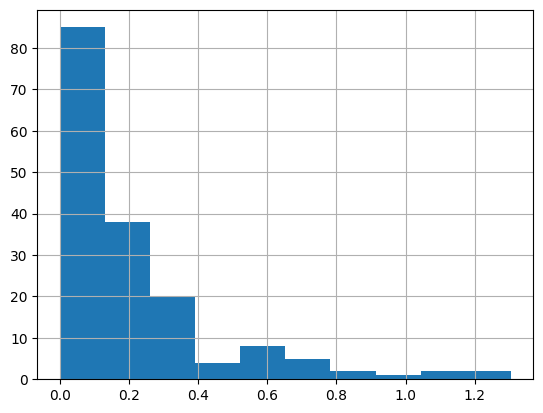

In [80]:
df_estimates['ARC_diff'].hist()

In [81]:
df_estimates.groupby('region')['ARC_n'].mean().sort_values(ascending=False)

region
Sub-Saharan Africa            0.559369
South Asia                    0.480230
Middle East & North Africa    0.345563
East Asia & Pacific           0.278435
Latin America & Caribbean     0.144425
Europe & Central Asia         0.111686
North America                 0.017158
Name: ARC_n, dtype: float64

<Axes: xlabel='ARC_r', ylabel='ARC_n'>

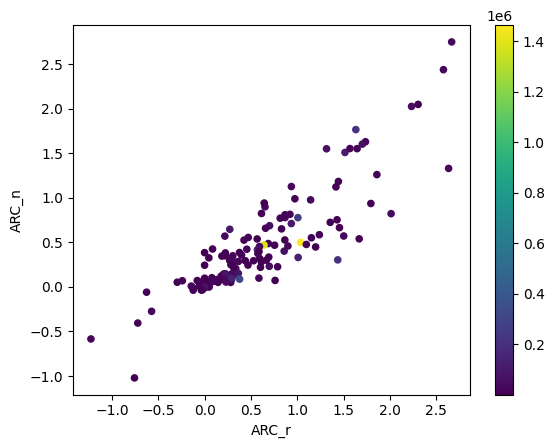

In [82]:
df_estimates.plot.scatter(x='ARC_r', y='ARC_n', c=df_estimates['pop_n'], colormap='viridis')


In [83]:
# mean of the population per region
df_estimates.groupby('region')['pop_n'].mean()

region
East Asia & Pacific            55432.447910
Europe & Central Asia          15696.887126
Latin America & Caribbean      13080.491514
Middle East & North Africa     29714.159598
North America                  72590.069802
South Asia                    183752.187668
Sub-Saharan Africa             20020.467541
Name: pop_n, dtype: float64

In [86]:
# sum of the population per region
df_estimates.groupby('region')['pop_n'].sum()

region
East Asia & Pacific           4.434596e+06
Europe & Central Asia         2.009202e+06
Latin America & Caribbean     1.255727e+06
Middle East & North Africa    5.942832e+05
North America                 7.259007e+05
South Asia                    4.042548e+06
Sub-Saharan Africa            2.082129e+06
Name: pop_n, dtype: float64